In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize





pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
# Fonction pour transformer et encoder les données
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
    return X

df = pd.read_csv('Data_Modelisation-3.csv')
df.Vitesse = df.Vitesse.astype(str)

In [8]:
# c = []
# v = []
# g = []
# cfl = []
# t = []
# for i in df.Contaminant.unique():
#     for j in df.Vitesse.unique():
#         a = df[(df.Contaminant == i) & (df.Vitesse == j) & (df.Glissement == 100)]["Moyenne CFL C"].median()
#         temp = df[(df.Contaminant == i) & (df.Vitesse == j) & (df.Glissement == 100)]['T° BDR (C)'].median()
#         for k in [40, 60,80]:
#             c+= [i]
#             v+= [j]
#             g+= [k]
#             cfl+= [(a+0.015) if k==40 else ( (a+0.01) if k==60 else (a+0.005))]
#             t+=[temp]


# more_data = pd.DataFrame({"Vitesse" : v,
#               "Glissement" : g,
#              "Moyenne CFL C" : cfl,
#              'Moyenne G% [%]' : g,
#               'T° BDR (C)' : t,
#               "Contaminant" : c
#              })
# df = pd.concat([df, more_data], axis = 0)



In [3]:
X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)

In [4]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


## Neige fraiche (B)

In [25]:
%%time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Fonction pour transformer et encoder les données
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
    return X

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']
# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=96)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14.18,15, 10)
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = {'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=[constraints])
        a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k[0]
        y_pred_train = np.where(mask,
                                a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

Meilleur point de coupure: [15.0, 0]
Paramètres: a1=0.026243404438038, b1=0.008025616101431356, c1=0.03833577609911023, d1=-0.0010498093993242818, e1=-0.005720043763209726, a2=0.056153103308022624, b2=-0.207029648720461, c2=-0.06729250387748242, d2=-0.0004554317543822682, e2=0.0008935297898525155
R² train: 0.6561895058672136
R² test: 0.7486562586240365
CPU times: total: 12.4 s
Wall time: 12.4 s


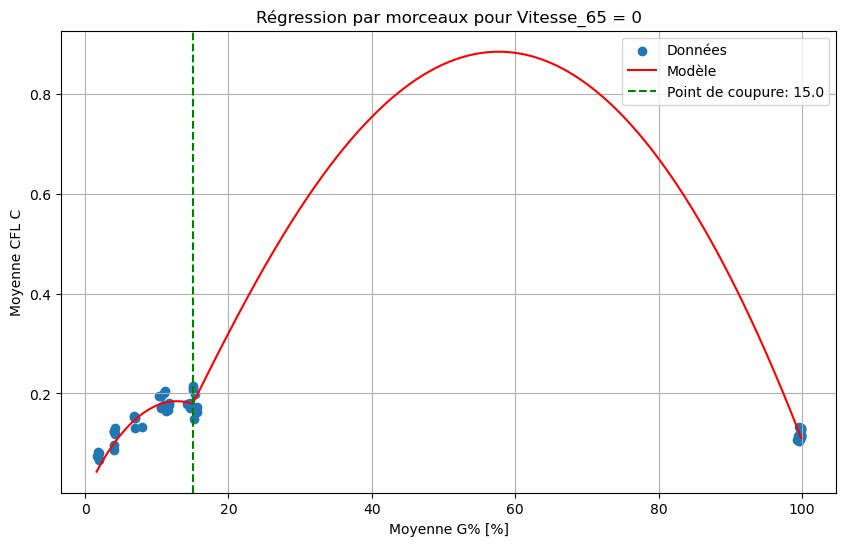

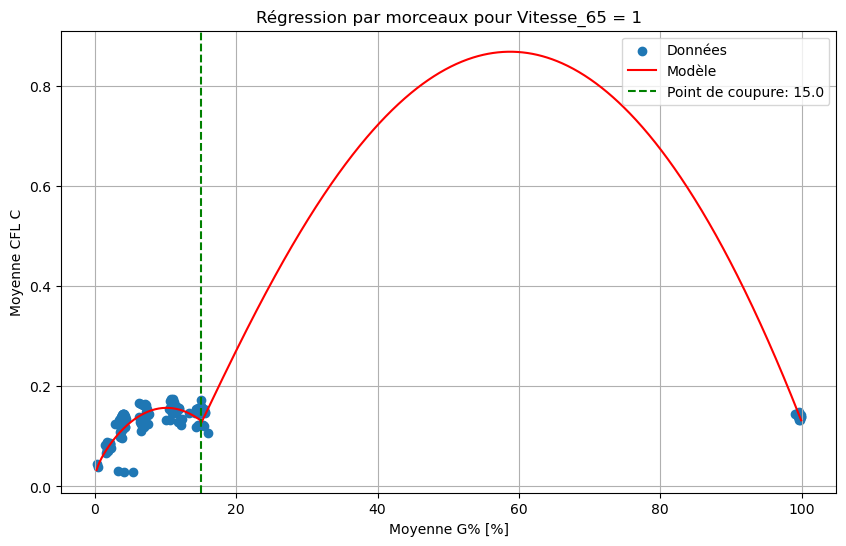

In [26]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

65Km\h glace ncc R² voir les variables 


## Neige fraiche (G)

In [15]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']
# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11.5,14, 10)
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = {'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=[constraints])
        a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k[0]
        y_pred_train = np.where(mask,
                                a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

Meilleur point de coupure: [11.5, 1]
Paramètres: a1=0.012151934779924076, b1=0.041576085830305205, c1=0.041582166402931386, d1=-0.0004667130404119226, e1=-0.006189058207106218, a2=-0.0051792513796383435, b2=0.09089997084671404, c2=-0.020525449391581754, d2=2.213197500637045e-05, e2=0.00044576431477021155
R² train: 0.8817604492463146
R² test: 0.7052656572616673
CPU times: total: 8.8 s
Wall time: 8.79 s


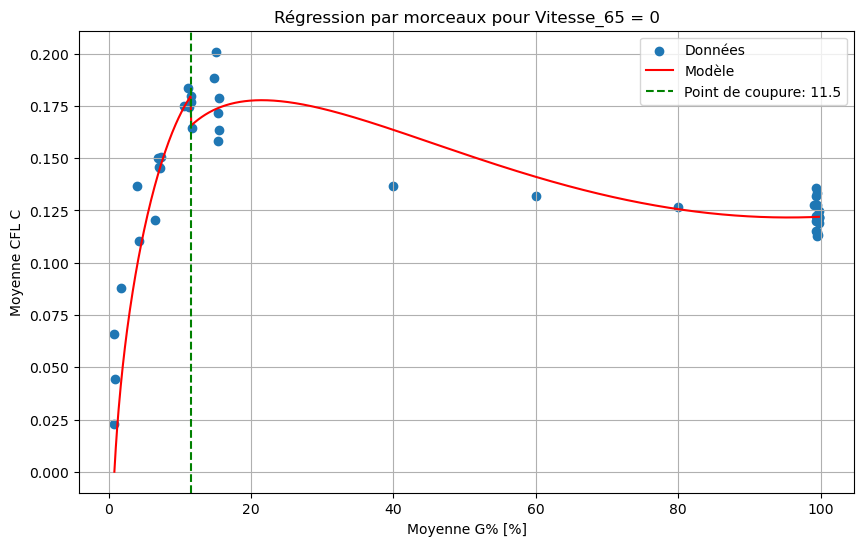

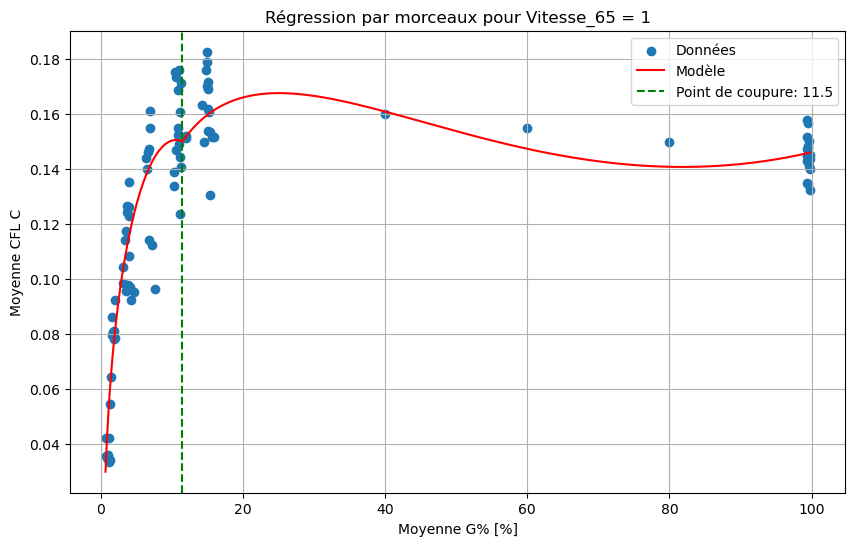

In [16]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## N.C. (G)

In [389]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [13.222222222222221, 1]
Paramètres: a1=0.046101754184364595, b1=-0.017080852502611283, c1=-0.013761483809841067, d1=-0.001995680694735363, e1=-0.0019075490767313835, a2=-0.00805328494394158, b2=0.12554966340352816, c2=-0.059748569465526334, d2=3.64268058975114e-05, e2=0.0010051147921140051
R² train: 0.895354886899651
R² test: 0.8738387601243973
CPU times: total: 7.27 s
Wall time: 7.28 s


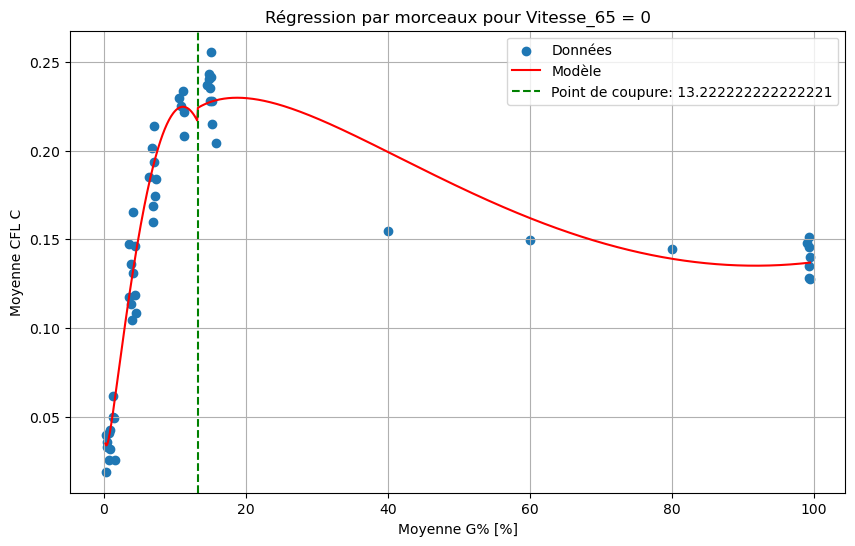

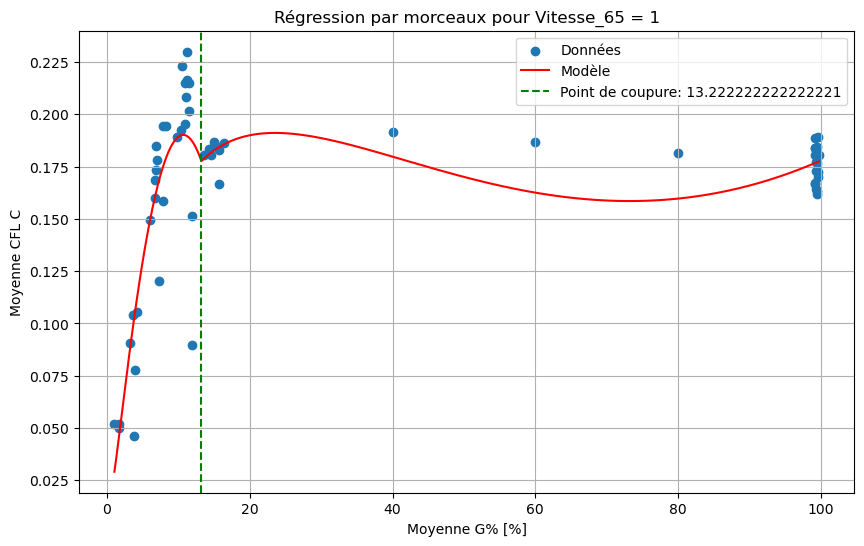

In [390]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## N.C. (B)

In [397]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14,16, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [14.0, 0]
Paramètres: a1=0.05392512343820592, b1=-0.038726033403085766, c1=0.009453540282885448, d1=-0.002228032393836429, e1=-0.003766857886002622, a2=-0.008551695554877753, b2=0.12408228117230814, c2=-0.002330009955729461, d2=4.2452249057968117e-05, e2=0.00030857367307280704
R² train: 0.8518415399873345
R² test: 0.8881478681972875
CPU times: total: 8.72 s
Wall time: 8.75 s


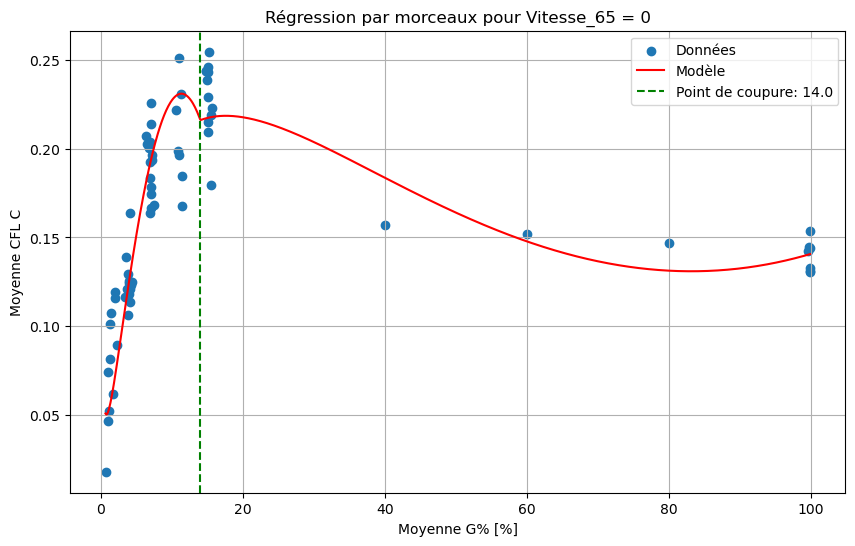

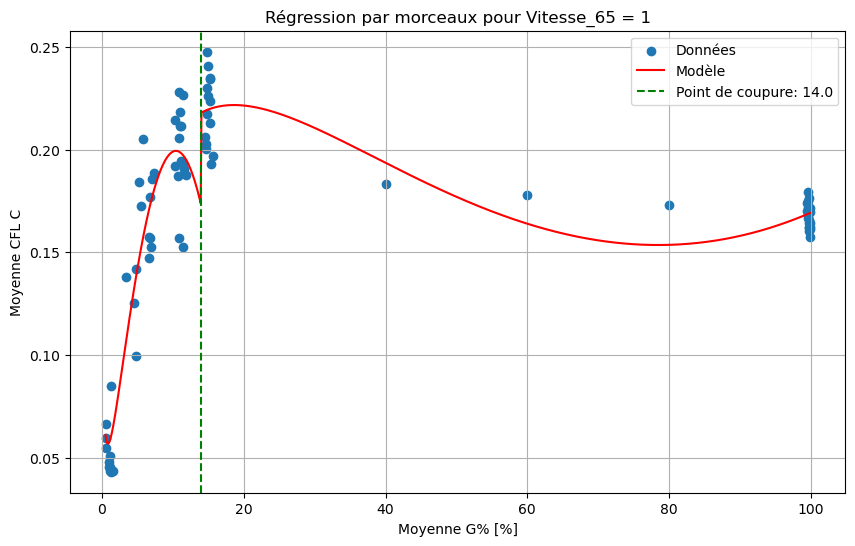

In [398]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## NC.C.


In [393]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(5,15, 15)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [8.571428571428571, 0]
Paramètres: a1=0.0728815536337856, b1=-0.007713000011301602, c1=-0.011533386895047218, d1=-0.00519232758655548, e1=-0.0014055455369960525, a2=-0.010542574854150239, b2=0.14570449347986789, c2=-0.01927472535083094, d2=5.416415163734468e-05, e2=0.00046980396149798786
R² train: 0.8540603532770836
R² test: 0.8253404070384581
CPU times: total: 11.8 s
Wall time: 11.8 s


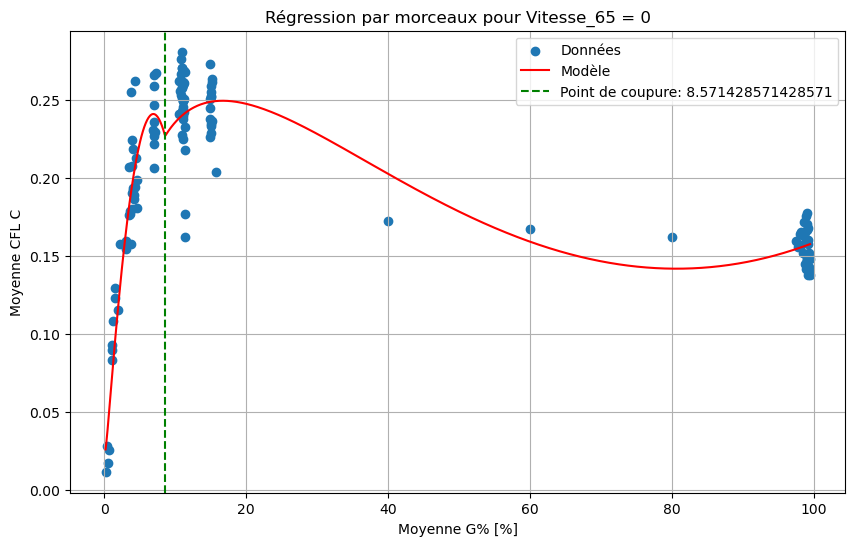

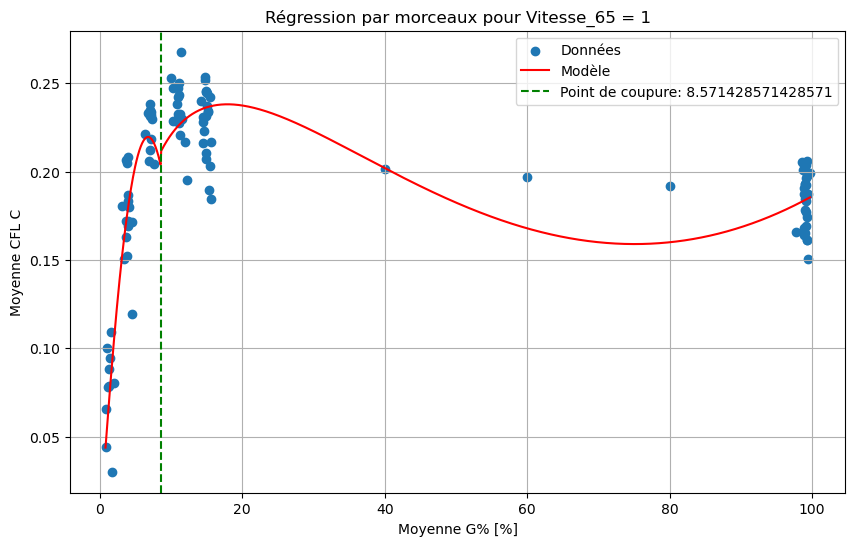

In [394]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## Verglas

In [400]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,20, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [10.526315789473685, 1]
Paramètres: a1=0.033288599079041324, b1=0.027485514877583193, c1=0.02317511395962683, d1=-0.002143180100834316, e1=-0.006122938151427114, a2=-0.0024012815705176465, b2=0.060558906850917665, c2=0.021595415202551982, d2=9.870619177425137e-06, e2=-0.0003424984533979917
R² train: 0.8447308192672971
R² test: 0.7746280865152058
CPU times: total: 14.5 s
Wall time: 14.6 s


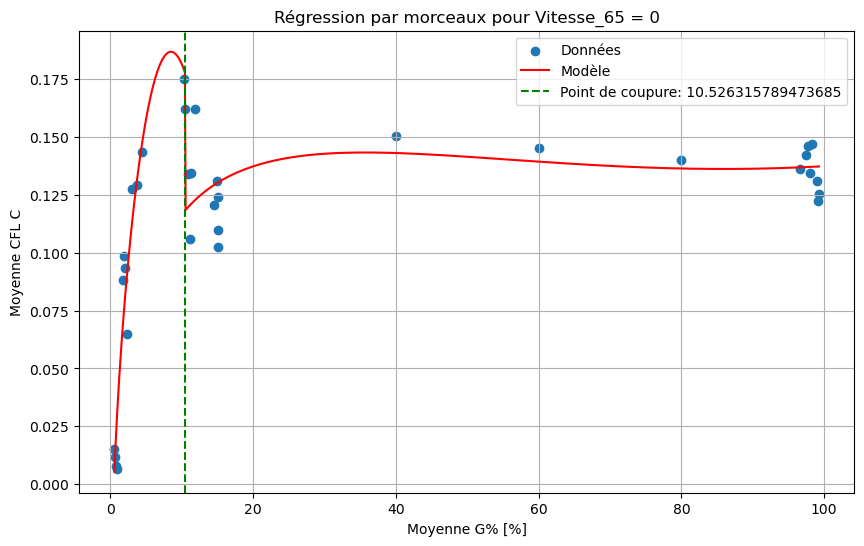

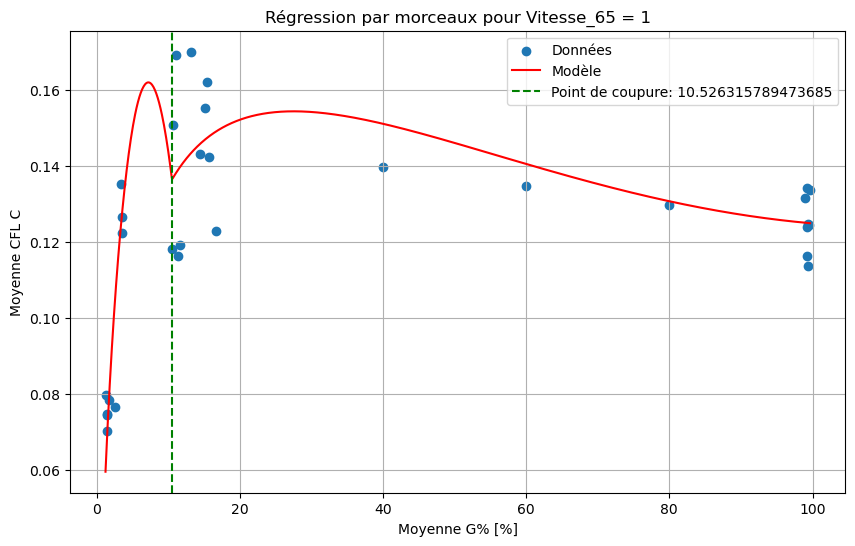

In [401]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))

    
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## Glace

In [404]:
%%time

def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
    return X

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]']+b2 * np.log(X['Moyenne G% [%]'])  + c2 * X['Vitesse_65']+d2 * (X['Moyenne G% [%]']**2)  + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14,16, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] +d2 * (X_train['Moyenne G% [%]']**2) +  e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [14.0, 1]
Paramètres: a1=0.059530085275080684, b1=-0.1453126205404947, c1=0.02811669101105725, d1=-0.0018944751655935069, e1=-0.0007758013829804321, a2=-0.0033219681295456028, b2=0.05352629686213492, c2=-0.0019063312727418593, d2=1.486808266646316e-05, e2=7.997967634223607e-06
R² train: 0.9058864871661069
R² test: 0.8264387643229392
CPU times: total: 9.08 s
Wall time: 9.08 s


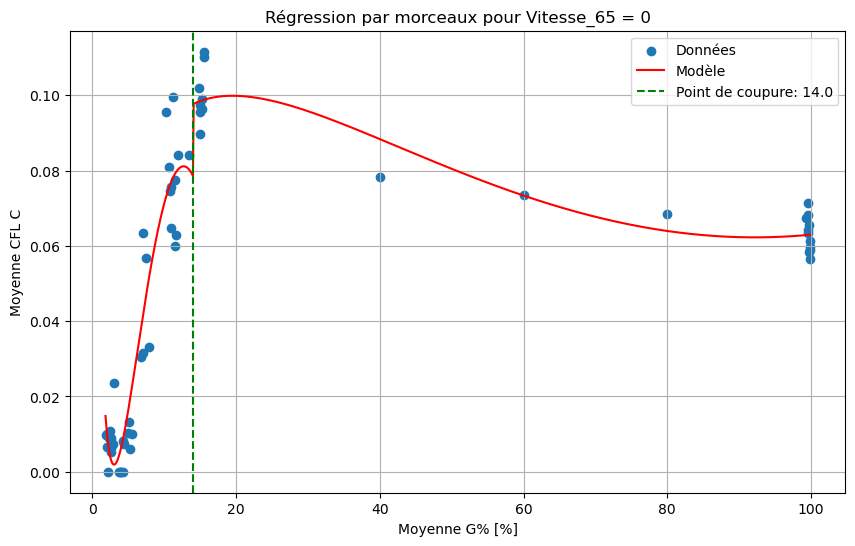

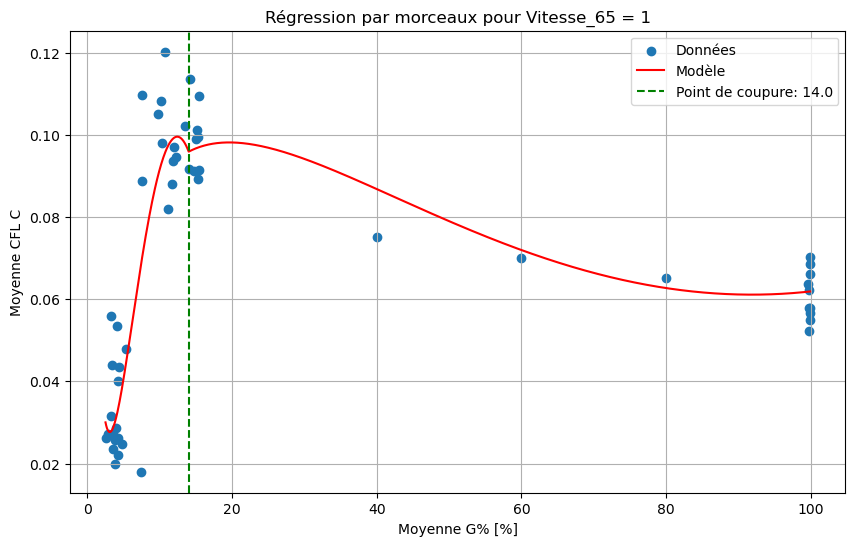

In [405]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()

## slush

In [406]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    glissement = x_k[0]
    vitesse = x_k[1]
    return (a1 * glissement + b1 * np.log(glissement) + c1 * vitesse + d1 * (glissement**2) + e1 * (glissement * vitesse)) - (a2 * glissement + b2 * np.log(glissement) + c2 * vitesse + d2 * (glissement**2) + e2 * (glissement * vitesse))

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = params
    mask = X['Moyenne G% [%]'] <= x_k[0]
    y_pred = np.where(mask,
                      a1 * X['Moyenne G% [%]'] + b1 * np.log(X['Moyenne G% [%]']) + c1 * X['Vitesse_65'] + d1 * (X['Moyenne G% [%]']**2) + e1 * (X['Moyenne G% [%]'] * X['Vitesse_65']),
                      a2 * X['Moyenne G% [%]'] + b2 * np.log(X['Moyenne G% [%]']) + c2 * X['Vitesse_65'] + d2 * (X['Moyenne G% [%]']**2) + e2 * (X['Moyenne G% [%]'] * X['Vitesse_65']))
    return mean_squared_error(y, y_pred)

# Chargement des données
data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = X.Vitesse_65 , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14,20, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    for x_vitesse in [0, 1]:  # Si Vitesse_65 est binaire
        x_k = [x_glissement, x_vitesse]
        initial_guess = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
        constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': [x_k]}]
        solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
        if solution.success:
            a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = solution.x
            mask = X_train['Moyenne G% [%]'] <= x_k[0]
            y_pred_train = np.where(mask,
                                    a1 * X_train['Moyenne G% [%]'] + b1 * np.log(X_train['Moyenne G% [%]']) + c1 * X_train['Vitesse_65'] + d1 * (X_train['Moyenne G% [%]']**2) + e1 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']),
                                    a2 * X_train['Moyenne G% [%]'] + b2 * np.log(X_train['Moyenne G% [%]']) + c2 * X_train['Vitesse_65'] + d2 * (X_train['Moyenne G% [%]']**2) + e2 * (X_train['Moyenne G% [%]'] * X_train['Vitesse_65']))
            r2_train = r2_score(y_train, y_pred_train)
            
            if r2_train > best_r2:
                best_r2 = r2_train
                best_params = solution.x
                best_x_k = x_k

# Affichage des résultats
a1, b1, c1, d1, e1, a2, b2, c2, d2, e2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, d1={d1}, e1={e1}, a2={a2}, b2={b2}, c2={c2}, d2={d2}, e2={e2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k[0]
y_pred_test = np.where(mask_test,
                       a1 * X_test['Moyenne G% [%]'] + b1 * np.log(X_test['Moyenne G% [%]']) + c1 * X_test['Vitesse_65'] + d1 * (X_test['Moyenne G% [%]']**2) + e1 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']),
                       a2 * X_test['Moyenne G% [%]'] + b2 * np.log(X_test['Moyenne G% [%]']) + c2 * X_test['Vitesse_65'] + d2 * (X_test['Moyenne G% [%]']**2) + e2 * (X_test['Moyenne G% [%]'] * X_test['Vitesse_65']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")




Meilleur point de coupure: [15.263157894736842, 0]
Paramètres: a1=0.01678469101325812, b1=-0.0008251943076838999, c1=0.002512237970626001, d1=-0.00046100000835161913, e1=0.00048624422819204527, a2=-0.0010727338043491615, b2=0.05966912548854111, c2=-0.025158724632765535, d2=1.2471335623655776e-06, e2=-0.00033719638883426497
R² train: 0.929500652136642
R² test: 0.8906962745203264
CPU times: total: 11.8 s
Wall time: 11.8 s


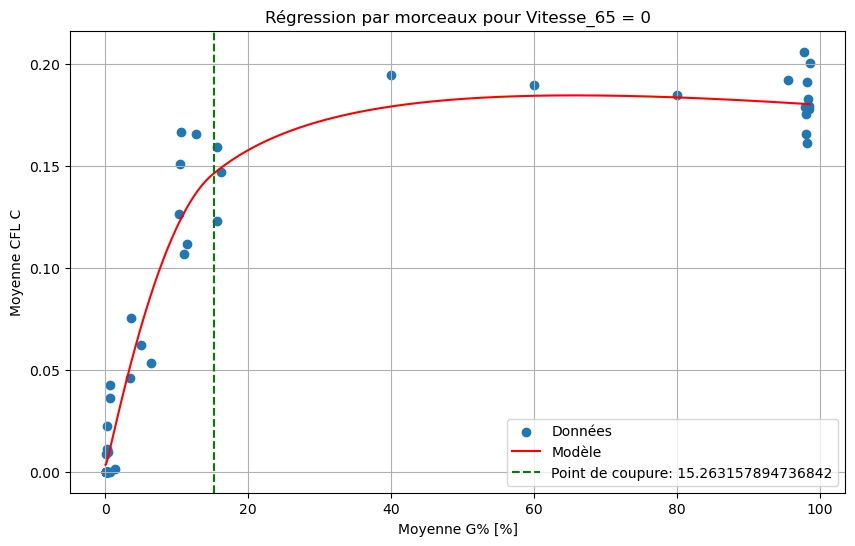

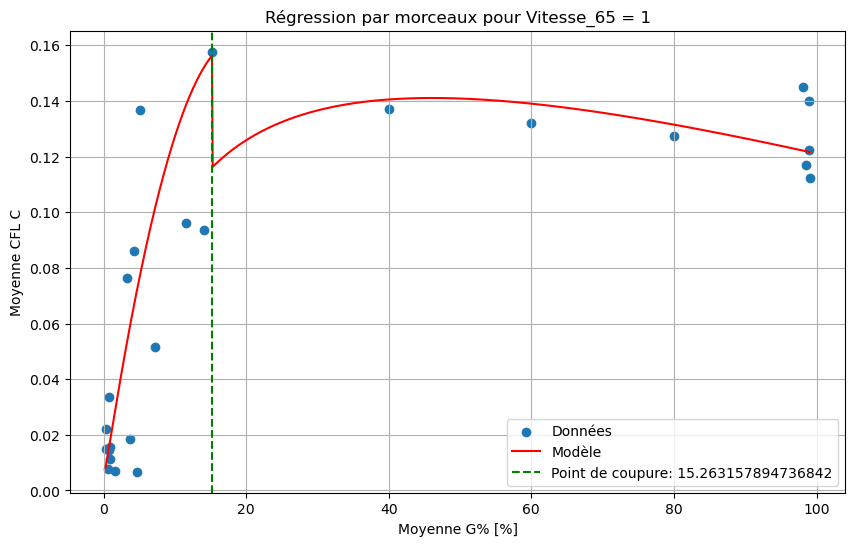

In [407]:
for i in [0,1]:
    X_v1 = X[X['Vitesse_65'] == i]
    y_v1 = y[X['Vitesse_65'] == i]
    
    # Créer une plage de valeurs pour x
    x = np.linspace(X_v1['Moyenne G% [%]'].min(), X_v1['Moyenne G% [%]'].max(), 1000)
    
    # Calculer les prédictions pour Vitesse_65 = 1
    y_pred_v1 = np.where(x <= best_x_k[0],
                         a1 * x + b1 * np.log(x) + c1 * i + d1 * (x**2) + e1 * (x * i),
                         a2 * x + b2 * np.log(x) + c2 * i + d2 * (x**2) + e2 * (x * i))
    
    # Tracer les résultats
    plt.figure(figsize=(10, 6))
    plt.scatter(X_v1['Moyenne G% [%]'], y_v1, label='Données')
    plt.plot(x, y_pred_v1, color='red', label='Modèle')
    plt.axvline(x=best_x_k[0], color='green', linestyle='--', label=f'Point de coupure: {best_x_k[0]}')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Régression par morceaux pour Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
    plt.show()